# M4.Ex1: Housing Prices Model (PyCaret)

### Name: Shaima Alqahtani

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M6/exercises/ex1_pycaret_regression.ipynb)

## Exercise

Your task is to follow the steps outlined here, and apply them on the **California Housing Dataset** below:

- [**🚀 Regression**](https://pycaret.gitbook.io/docs/get-started/quickstart#regression)
    - Setup
    - Compare Models
    - Analyze Model
    - Predictions
    - Save the model

## California Housing Prices Dataset


Find and download the dataset from Kaggle at [California Housing Dataset](https://www.kaggle.com/datasets/dhirajnirne/california-housing-data).

According to [keras.io](https://keras.io/api/datasets/california_housing/):

> This dataset was obtained from the StatLib repository.
>
> It's a continuous regression dataset with 20,640 samples with 8 features each.
>
> The target variable is a scalar: the median house value for California districts, in dollars.
>
> The 8 input features are the following:
>
> - MedInc: median income in block group
> - HouseAge: median house age in block group
> - AveRooms: average number of rooms per household
> - AveBedrms: average number of bedrooms per household
> - Population: block group population
> - AveOccup: average number of household members
> - Latitude: block group latitude
> - Longitude: block group longitude
>
> This dataset was derived from the 1990 U.S. census, using one row per census block group. A block group is the smallest geographical unit for which the U.S. Census Bureau publishes sample data (a block group typically has a population of 600 to 3,000 people).
>
> A household is a group of people residing within a home. Since the average number of rooms and bedrooms in this dataset are provided per household, these columns may take surprisingly large values for block groups with few households and many empty houses, such as vacation resorts.

### Load the data

In [29]:
import pandas as pd
import numpy

df = pd.read_csv(r'C:\Users\Dell\OneDrive\سطح المكتب\Auto Machine Learning\E1\housing.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


**Task**: Your model should learn from this data and be able to predict the median housing price (`median_house_value`) in any district, given all the other metrics.

Please read the above dataset description to understand what the features mean.

In [4]:
import pycaret
print(pycaret.__version__)

3.3.2


In [30]:
# Setup PyCaret
from pycaret.regression import *
reg_exp = setup(
    data=df,
    target='median_house_value',
    session_id=123,
    verbose=True
)

,Description,Value
0,Session id,123
1,Target,median_house_value
2,Target type,Regression
3,Original data shape,"(20640, 10)"
4,Transformed data shape,"(20640, 14)"
5,Transformed train set shape,"(14447, 14)"
6,Transformed test set shape,"(6193, 14)"
7,Numeric features,8
8,Categorical features,1
9,Rows with missing values,1.0%


In [31]:
# Compare models
best_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,32446.5243,2352506625.5720,48484.5478,0.8231,0.2376,0.1806,0.1550
rf,Random Forest Regressor,32601.1401,2500102516.8196,49989.2760,0.8121,0.2415,0.1817,2.1620
et,Extra Trees Regressor,35279.0180,2805036753.3820,52947.4818,0.7892,0.2522,0.1955,0.9050
gbr,Gradient Boosting Regressor,39009.2448,3150819000.1502,56118.7995,0.7633,0.2736,0.2186,0.6580
lr,Linear Regression,50154.1376,4757779475.9005,68960.1376,0.6429,0.3811,0.2885,0.0270
lasso,Lasso Regression,50154.5348,4757787550.5767,68960.2055,0.6429,0.3811,0.2885,0.0380
ridge,Ridge Regression,50155.4032,4757762702.3264,68960.0498,0.6429,0.3810,0.2885,0.0190
llar,Lasso Least Angle Regression,50154.5079,4757786154.0176,68960.1951,0.6429,0.3811,0.2885,0.0210
br,Bayesian Ridge,50167.2546,4759928809.4993,68976.0109,0.6428,0.3809,0.2887,0.0230
lar,Least Angle Regression,50318.6460,4895005267.5488,69952.2585,0.6326,0.4105,0.2860,0.0200


In [32]:
# Create the best model
model = create_model(best_model)
print(best_model)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,31916.6222,2183766376.9586,46730.7862,0.8486,0.2255,0.1734
1,32171.0813,2208022920.0618,46989.6044,0.8359,0.2222,0.1699
2,33074.5929,2458807837.0992,49586.3675,0.8155,0.2370,0.1805
3,32504.7909,2494434275.7584,49944.3117,0.8236,0.2353,0.1760
4,31650.1899,2155139986.2892,46423.4853,0.8447,0.2288,0.1763
5,32695.7509,2393963003.1411,48928.1412,0.8022,0.2474,0.1874
6,32628.8229,2313740255.6973,48101.3540,0.8241,0.2467,0.1899
7,32698.6946,2331913339.7254,48289.8886,0.8239,0.2465,0.1895
8,32531.0013,2516408893.3986,50163.8206,0.8050,0.2450,0.1821


LGBMRegressor(n_jobs=-1, random_state=123)


In [33]:
# Tune the model
tuned_model = tune_model(model)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,31393.0987,2147379295.9584,46339.8241,0.8512,0.2287,0.1743
1,31818.8379,2123580096.2353,46082.3187,0.8422,0.2189,0.1673
2,32316.4499,2381339136.6452,48798.9666,0.8213,0.2366,0.1775
3,32260.8591,2532793715.7580,50326.8687,0.8209,0.2377,0.1750
4,32086.3043,2203695226.3152,46943.5323,0.8412,0.2341,0.1815
5,32691.2259,2327642606.8363,48245.6486,0.8077,0.2446,0.1860
6,33430.1860,2389219661.5966,48879.6447,0.8183,0.2518,0.1958
7,32495.2003,2290333290.0491,47857.4267,0.8270,0.2431,0.1858
8,32316.1415,2482451746.9026,49824.2084,0.8076,0.2439,0.1810


Fitting 10 folds for each of 10 candidates, totalling 100 fits


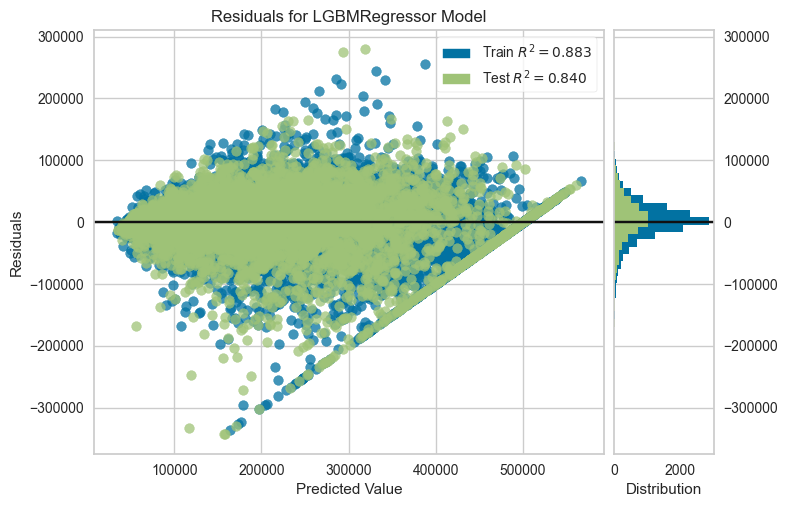

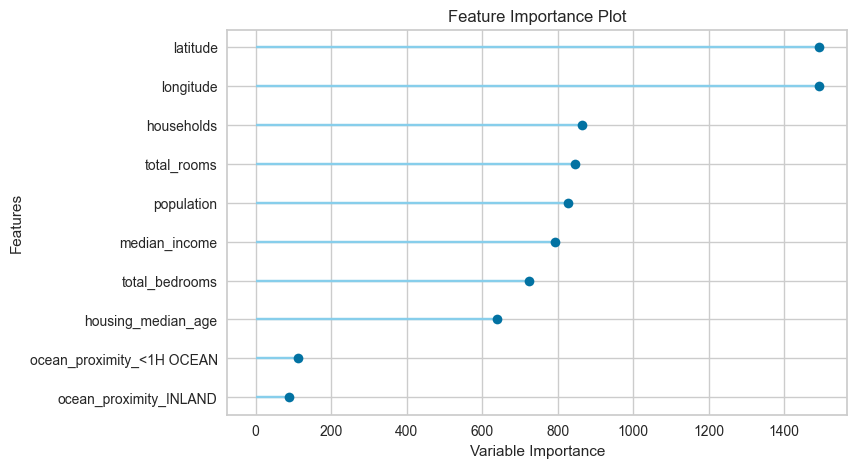

In [34]:
# Analyze model
plot_model(tuned_model, plot='residuals')
plot_model(tuned_model, plot='feature')

In [36]:
# Predict on the same dataset
predictions = predict_model(tuned_model)
print(predictions)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,31314.4619,2120156683.4171,46045.1592,0.8397,0.2318,0.1777


[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
        longitude   latitude  housing_median_age  total_rooms  total_bedrooms  \
19121 -122.639999  38.240002                40.0       1974.0           410.0   
20019 -119.050003  36.090000                 9.0       3297.0           568.0   
15104 -116.980003  32.849998                12.0       3570.0           713.0   
3720  -118.419998  34.200001                27.0       3201.0           970.0   
8938  -118.470001  34.009998                41.0       2704.0           557.0   
...           ...        ...                 ...          ...             ...   
1859  -124.139999  41.950001                21.0       2696.0           578.0   
108

In [37]:
# Save the model
save_model(tuned_model, "california_price_model")

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['longitude', 'latitude',
                                              'housing_median_age',
                                              'total_rooms', 'total_bedrooms',
                                              'population', 'households',
                                              'median_income'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=['ocean_proximity'],
                                     transformer=SimpleImputer(strategy='mo...
                  TransformerWrapper(include=['ocean_proximity'],
                                     transformer=OneHotEncoder(cols=['ocean_proximity'],
                                                               handle_missing='return_nan',
                                                               u